<a href="https://colab.research.google.com/github/NirikshaHP/Airfoil-Self-Noise-Prediction/blob/main/airfoil_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel('/content/Airfoil-nir.xlsx')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
dataset = pd.read_excel('/content/Airfoil-nir.xlsx')
dataset

,Frequency,attack-angle,chord-length,free-stream-velocity,suction-side-displacement-thickness,scaled-sound-pressure
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461
...,...,...,...,...,...,...
1498,2500,15.6,0.1016,39.6,0.052849,110.264
1499,3150,15.6,0.1016,39.6,0.052849,109.254
1500,4000,15.6,0.1016,39.6,0.052849,106.604
1501,5000,15.6,0.1016,39.6,0.052849,106.224


In [ ]:
df.columns = [
    'frequency',
    'attack_angle',
    'chord_length',
    'free_stream_velocity',
    'suction_side_displacement',
    'scaled_sound_pressure'
]

In [ ]:
df.head()

,frequency,attack_angle,chord_length,free_stream_velocity,suction_side_displacement,scaled_sound_pressure
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   frequency                  1503 non-null   int64  
 1   attack_angle               1503 non-null   float64
 2   chord_length               1503 non-null   float64
 3   free_stream_velocity       1503 non-null   float64
 4   suction_side_displacement  1503 non-null   float64
 5   scaled_sound_pressure      1503 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 70.6 KB


In [ ]:
df.describe()

,frequency,attack_angle,chord_length,free_stream_velocity,suction_side_displacement,scaled_sound_pressure
count,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000
mean,2886.380572,6.782302,0.136548,50.860745,0.011140,124.835943
std,3152.573137,5.918128,0.093541,15.572784,0.013150,6.898657
min,200.000000,0.000000,0.025400,31.700000,0.000401,103.380000
25%,800.000000,2.000000,0.050800,39.600000,0.002535,120.191000
50%,1600.000000,5.400000,0.101600,39.600000,0.004957,125.721000
75%,4000.000000,9.900000,0.228600,71.300000,0.015576,129.995500
max,20000.000000,22.200000,0.304800,71.300000,0.058411,140.987000


In [ ]:
print(df.columns)

Index(['frequency', 'attack_angle', 'chord_length', 'free_stream_velocity',
       'suction_side_displacement', 'scaled_sound_pressure'],
      dtype='object')


In [ ]:
df.shape

(1503, 6)

In [ ]:
df.isnull().sum()

,0
frequency,0
attack_angle,0
chord_length,0
free_stream_velocity,0
suction_side_displacement,0
scaled_sound_pressure,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

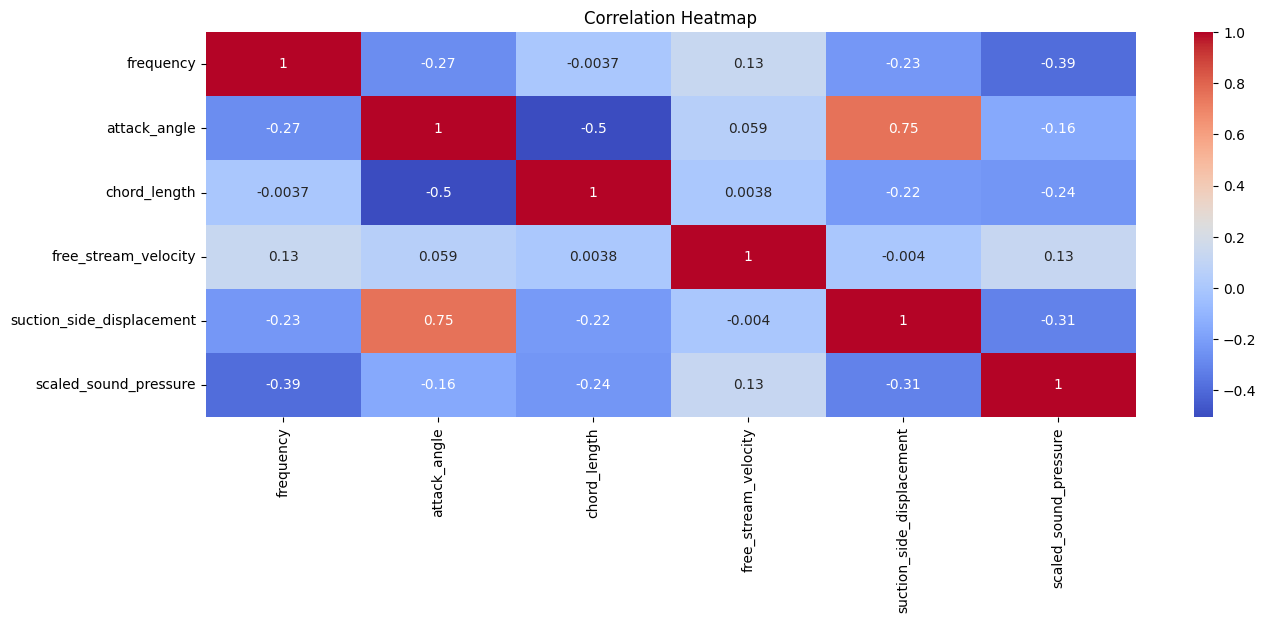

Observation:
The heatmap shows relationships between features and the target variable.
Features with higher correlation values have stronger influence on sound pressure.
Some features show weak correlations, indicating possible nonlinear relationships.
This supports the use of Decision Tree and Random Forest models.


In [ ]:
plt.figure(figsize=(15,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()
print("Observation:")
print("The heatmap shows relationships between features and the target variable.")
print("Features with higher correlation values have stronger influence on sound pressure.")
print("Some features show weak correlations, indicating possible nonlinear relationships.")
print("This supports the use of Decision Tree and Random Forest models.")

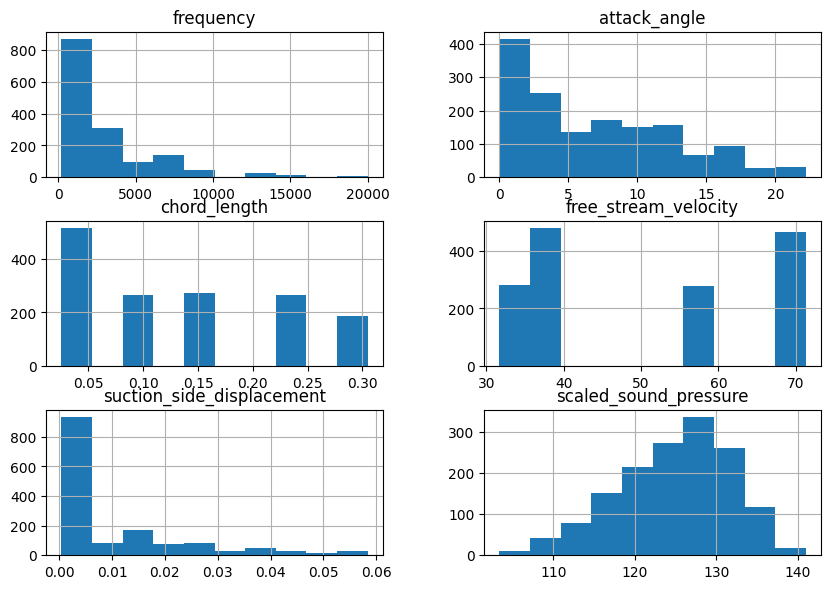

Observation:
Histograms show the distribution of each feature.
Some variables are normally distributed while others are skewed.
Feature scales differ significantly across variables.
Therefore, feature scaling is required before model training.


In [ ]:
df.hist(figsize=(10,6.8))
plt.show()
print("Observation:")
print("Histograms show the distribution of each feature.")
print("Some variables are normally distributed while others are skewed.")
print("Feature scales differ significantly across variables.")
print("Therefore, feature scaling is required before model training.")

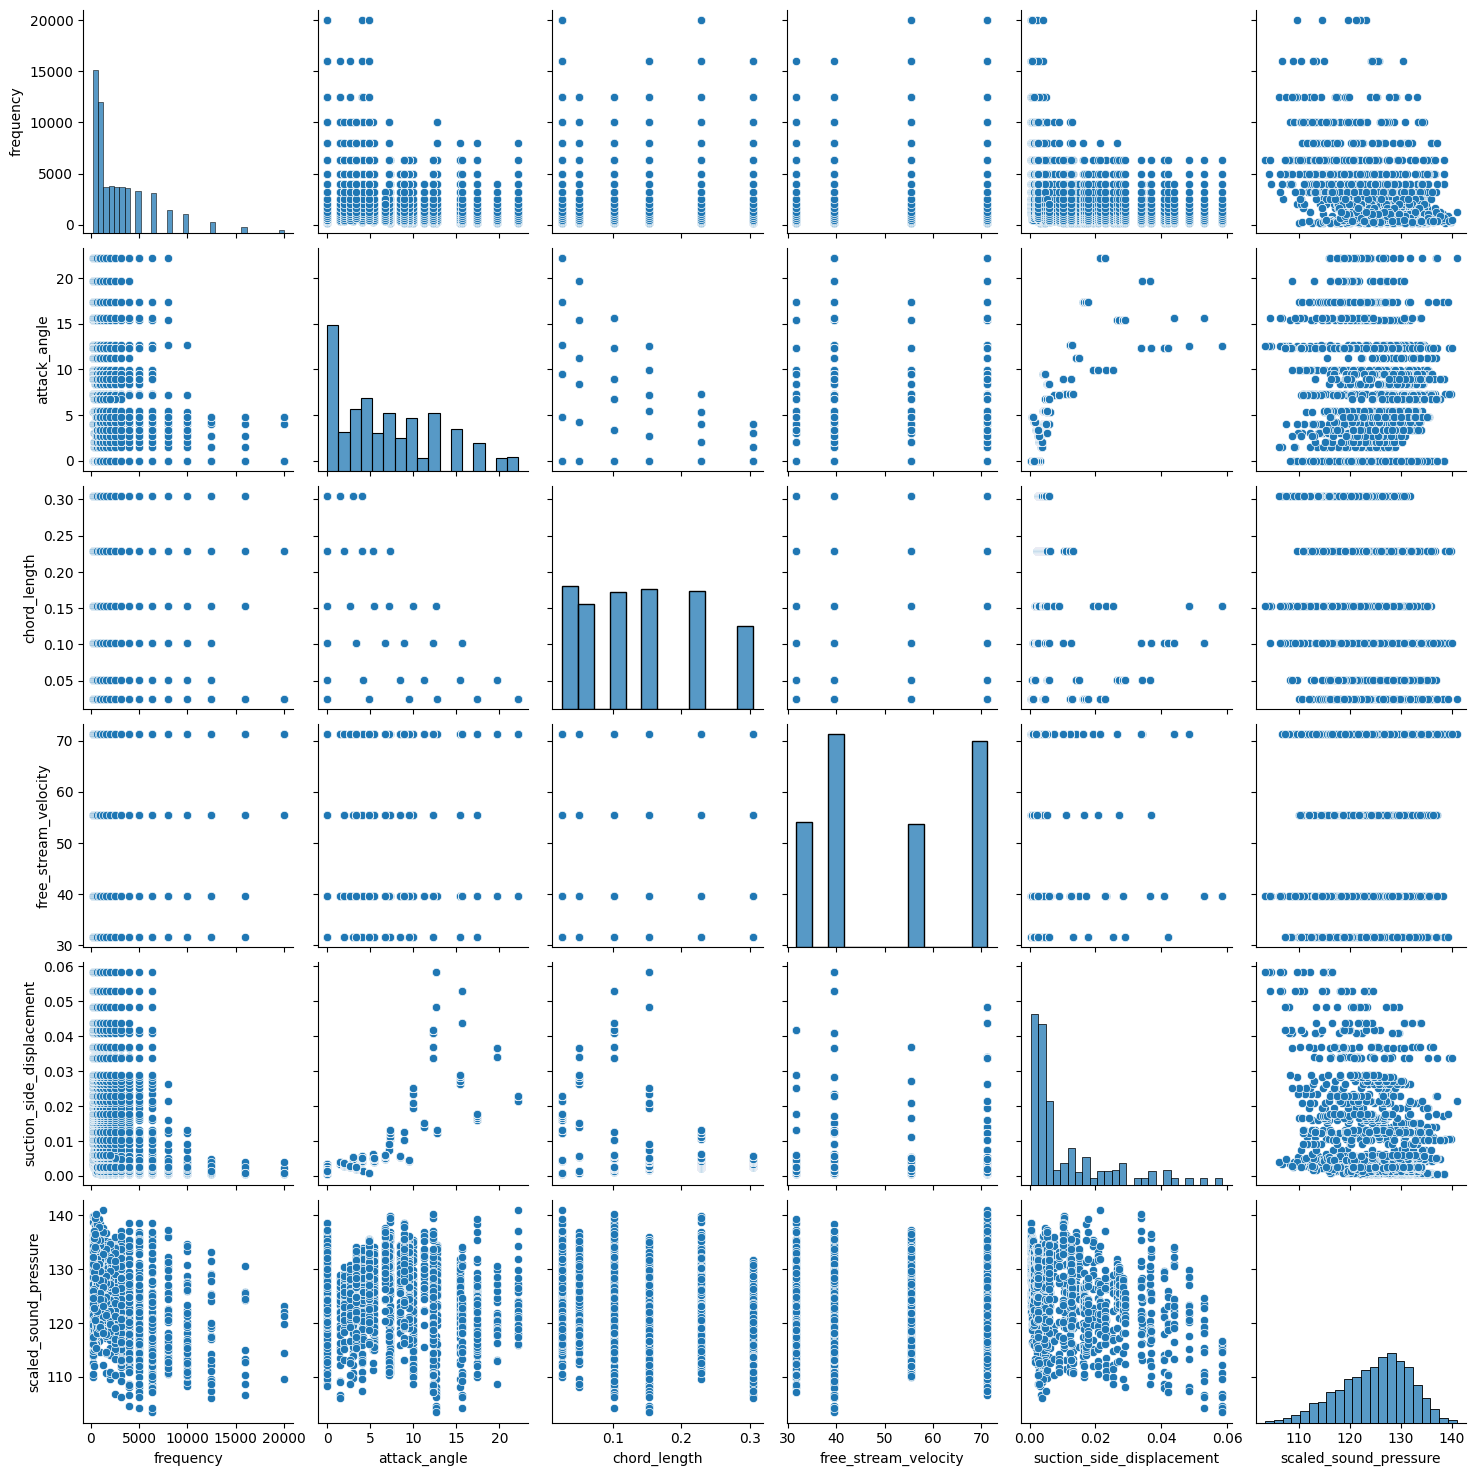

Observation:
The pairplot displays pairwise relationships among variables.
Some features show visible trends with the target variable.
Certain relationships appear nonlinear.
This justifies the use of nonlinear regression models.


In [ ]:
sns.pairplot(df)
plt.show()
print("Observation:")
print("The pairplot displays pairwise relationships among variables.")
print("Some features show visible trends with the target variable.")
print("Certain relationships appear nonlinear.")
print("This justifies the use of nonlinear regression models.")

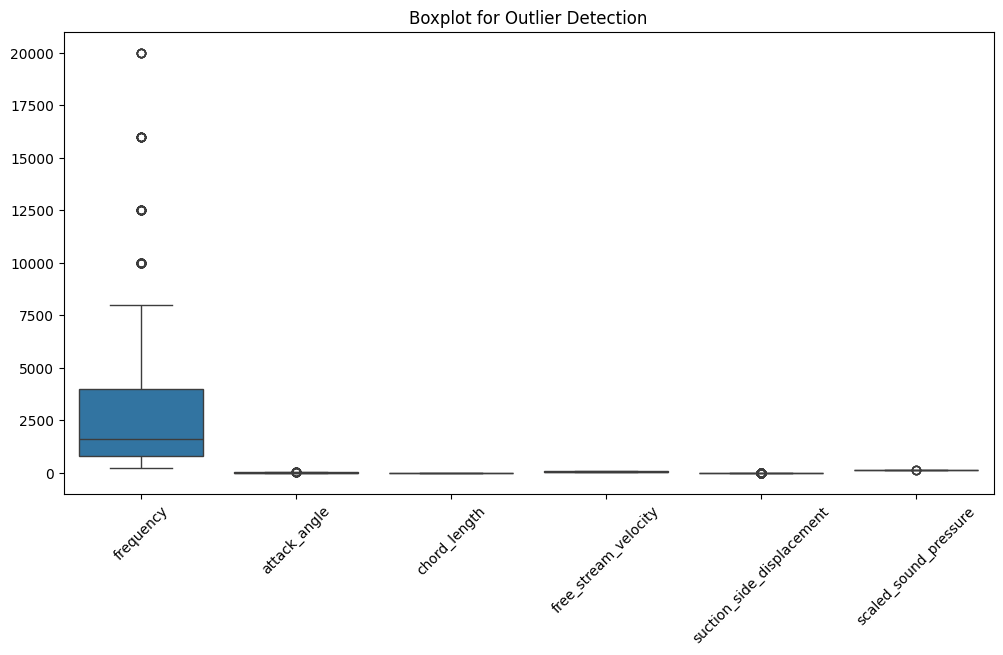

Observation:
The boxplot is used to detect outliers.
Several features contain outlier values.
Tree-based models are generally robust to outliers.
This makes Decision Tree and Random Forest suitable choices.


In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplot for Outlier Detection")
plt.show()
print("Observation:")
print("The boxplot is used to detect outliers.")
print("Several features contain outlier values.")
print("Tree-based models are generally robust to outliers.")
print("This makes Decision Tree and Random Forest suitable choices.")

In [ ]:
print(df.columns)

Index(['frequency', 'attack_angle', 'chord_length', 'free_stream_velocity',
       'suction_side_displacement', 'scaled_sound_pressure'],
      dtype='object')


In [ ]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [ ]:
X = df.drop('scaled_sound_pressure', axis=1)
y = df['scaled_sound_pressure']
print("Target Variable Explanation:")
print("The target variable is scaled_sound_pressure.")
print("It represents the sound pressure level generated by an airfoil.")
print("The objective is to predict sound pressure using aerodynamic parameters.")
print("Since the target variable is continuous, this is a regression problem.")

Target Variable Explanation:
The target variable is scaled_sound_pressure.
It represents the sound pressure level generated by an airfoil.
The objective is to predict sound pressure using aerodynamic parameters.
Since the target variable is continuous, this is a regression problem.


In [ ]:
print("Model Selection:")
print("KNN is used to capture local patterns in the data.")
print("Decision Tree can model nonlinear relationships.")
print("Random Forest reduces overfitting and improves prediction accuracy.")
print("These models are suitable for regression tasks involving complex relationships.")

Model Selection:
KNN is used to capture local patterns in the data.
Decision Tree can model nonlinear relationships.
Random Forest reduces overfitting and improves prediction accuracy.
These models are suitable for regression tasks involving complex relationships.


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [ ]:
print("KNN Results")
print("MAE :", mean_absolute_error(y_test, y_pred_knn))
print("MSE :", mean_squared_error(y_test, y_pred_knn))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_knn)))
print("R2 Score :", r2_score(y_test, y_pred_knn))

KNN Results
MAE : 2.417124916943522
MSE : 10.885640956411965
RMSE : 3.2993394727448044
R2 Score : 0.7827155700695738


In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [ ]:
print("Decision Tree Results")
print("MAE :", mean_absolute_error(y_test, y_pred_dt))
print("MSE :", mean_squared_error(y_test, y_pred_dt))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("R2 Score :", r2_score(y_test, y_pred_dt))

Decision Tree Results
MAE : 1.7340066445182718
MSE : 5.876174498338868
RMSE : 2.424082197108602
R2 Score : 0.8827077586744035


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [ ]:
print("Random Forest Results")
print("MAE :", mean_absolute_error(y_test, y_pred_rf))
print("MSE :", mean_squared_error(y_test, y_pred_rf))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score :", r2_score(y_test, y_pred_rf))

Random Forest Results
MAE : 1.3138023255813964
MSE : 3.2920289819322273
RMSE : 1.8143949354901283
R2 Score : 0.9342889735645517


In [ ]:
results = pd.DataFrame({

    'Model': [
        'KNN',
        'Decision Tree',
        'Random Forest'
    ],

    'MAE': [
        mean_absolute_error(y_test, y_pred_knn),
        mean_absolute_error(y_test, y_pred_dt),
        mean_absolute_error(y_test, y_pred_rf)
    ],

    'MSE': [
        mean_squared_error(y_test, y_pred_knn),
        mean_squared_error(y_test, y_pred_dt),
        mean_squared_error(y_test, y_pred_rf)
    ],

    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_knn)),
        np.sqrt(mean_squared_error(y_test, y_pred_dt)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ],

    'R2 Score': [
        r2_score(y_test, y_pred_knn),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf)
    ]
})

results

,Model,MAE,MSE,RMSE,R2 Score
0,KNN,2.417125,10.885641,3.299339,0.782716
1,Decision Tree,1.734007,5.876174,2.424082,0.882708
2,Random Forest,1.313802,3.292029,1.814395,0.934289


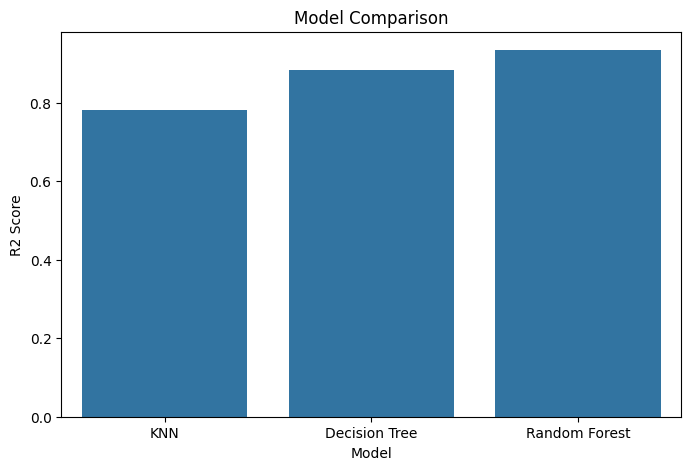

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=results
)
plt.title('Model Comparison')
plt.show()

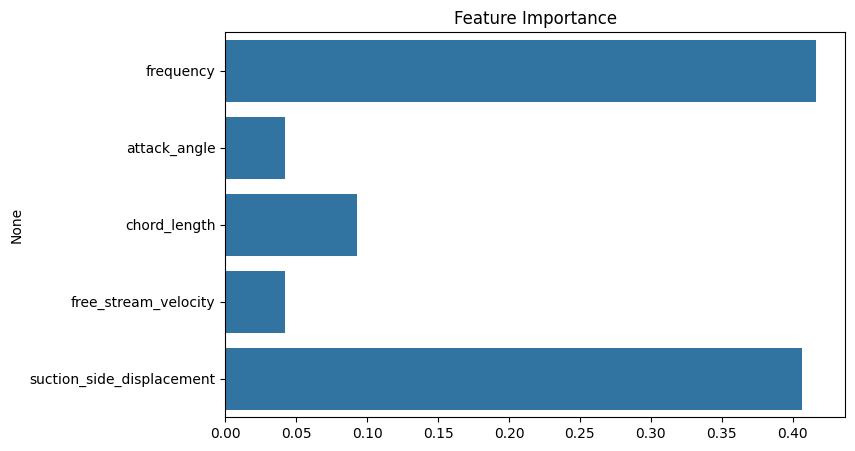

In [ ]:
# Feature importance graph
importance = rf.feature_importances_
features = X.columns
plt.figure(figsize=(8,5))
sns.barplot(
    x=importance,
    y=features
)
plt.title('Feature Importance')
plt.show()

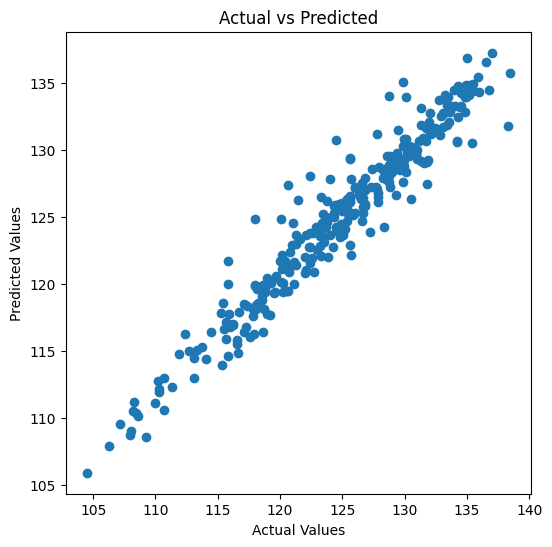

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')
plt.show()

In [ ]:
results.sort_values(
    by='R2 Score',
    ascending=False
)

,Model,MAE,MSE,RMSE,R2 Score
2,Random Forest,1.313802,3.292029,1.814395,0.934289
1,Decision Tree,1.734007,5.876174,2.424082,0.882708
0,KNN,2.417125,10.885641,3.299339,0.782716
